## Project: House Price Prediction using Linear & Regularized Regression (Ridge, Lasso, Elastic Net)

#### Goal: 
Build and compare linear and regularized regression models to predict house prices, analyze model performance, and understand the impact of regularization on overfitting and generalization.

#### Model Type: Regression Models (Supervised Learning)

#### Definition : 
Regression is a supervised learning technique used to predict continuous values. Linear Regression models the relationship between a continuous target variable (y) and one or more features (X) by fitting a linear equation:

y ≈ β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

The model estimates coefficients by minimizing the sum of squared errors between predicted and actual values (Ordinary Least Squares).

#### Models Used:

##### 1) Linear Regression:
- Baseline model that assumes a linear relationship between features and target  
- Easy to interpret and fast to train  
- Can overfit when data has noise or multicollinearity  

##### 2) Ridge Regression (L2 Regularization):
- Adds a penalty on squared coefficients to reduce model complexity  
- Shrinks coefficients but does not eliminate them  
- Helps handle multicollinearity and improves generalization  

##### 3) Lasso Regression (L1 Regularization):
- Adds a penalty on absolute values of coefficients  
- Can shrink some coefficients to zero → performs feature selection  
- Useful when many features are irrelevant  

##### 4) Elastic Net (L1 + L2):
- Combines both L1 and L2 penalties  
- Balances feature selection and coefficient stability  
- Works well when features are highly correlated  

#### Use Cases:
- House price prediction based on property features  
- Sales and revenue forecasting  
- Economic and financial modeling  
- Predicting medical outcomes (e.g., hospital stay duration)  
- Experimental data modeling (dose-response relationships)  

#### Evaluation Metrics:
- R² Score: Measures how well the model explains variance in target  
- RMSE: Measures prediction error magnitude  
- Train-Test Comparison: Helps detect overfitting or underfitting

#### Assumptions:
- Linearity between features and target  
- Independence of observations  
- Constant variance of errors (Homoscedasticity)  
- Normally distributed residuals  
- Low multicollinearity among features  

#### Why Regularization?
- Linear Regression may overfit with many features or noisy data  
- Regularization penalizes large coefficients  
- Helps reduce variance and improve model generalization  
- Balances bias-variance tradeoff

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

In [3]:
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 8)
Target shape: (20640,)


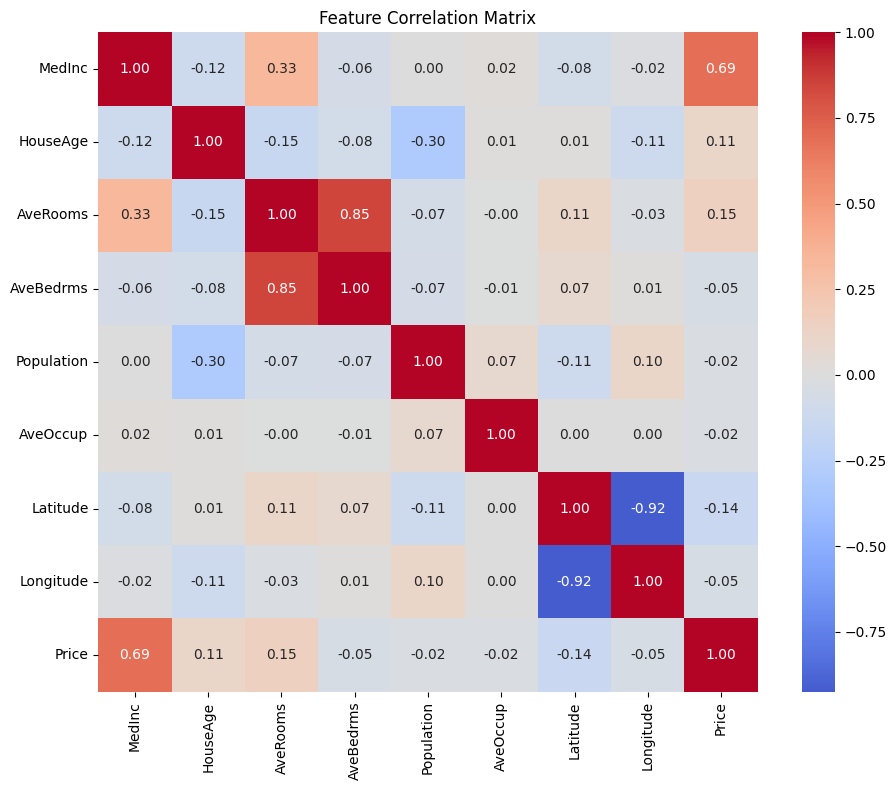

In [4]:
plt.figure(figsize=(10, 8))
correlation_matrix = pd.concat([X, pd.Series(y, name='Price')], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

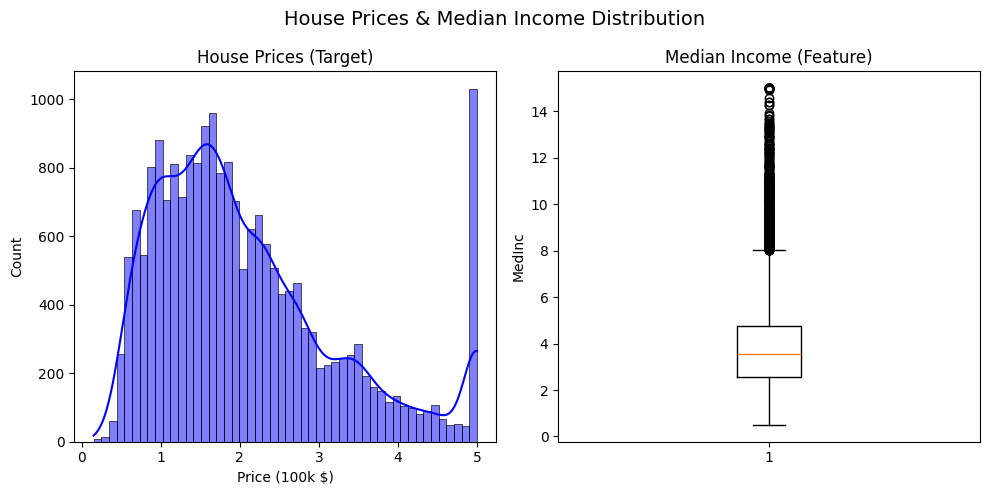

In [5]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('House Prices & Median Income Distribution', fontsize=14)

# Advanced seaborn histogram + KDE on top
sns.histplot(y, bins=50, kde=True, ax=ax1, color='blue', edgecolor='black')
ax1.set_title('House Prices (Target)')
ax1.set_xlabel('Price (100k $)')
ax1.set_ylabel('Count')

# Boxplot on bottom
ax2.boxplot(X['MedInc'], vert=True)
ax2.set_title('Median Income (Feature)')
ax2.set_ylabel('MedInc')

plt.tight_layout()
plt.show()

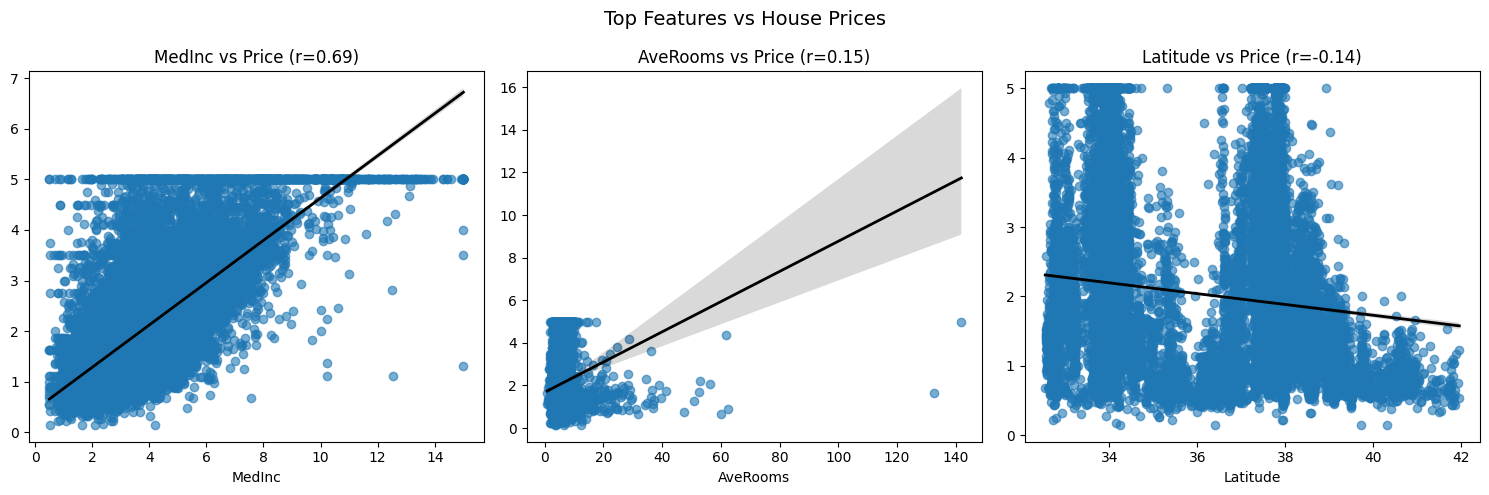

In [6]:
data_for_corr = pd.concat([X[['MedInc', 'AveRooms', 'Latitude']], pd.Series(y, name='Price')], axis=1)
corr_medinc = data_for_corr['MedInc'].corr(data_for_corr['Price'])
corr_rooms = data_for_corr['AveRooms'].corr(data_for_corr['Price'])
corr_lat = data_for_corr['Latitude'].corr(data_for_corr['Price'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Top Features vs House Prices', fontsize=14)

# Plot 1: MedInc
sns.regplot(x=X['MedInc'], y=y, ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={'color':'black', 'lw':2})
axes[0].set_title(f'MedInc vs Price (r={corr_medinc:.2f})')

# Plot 2: AveRooms  
sns.regplot(x=X['AveRooms'], y=y, ax=axes[1], scatter_kws={'alpha':0.6}, line_kws={'color':'black', 'lw':2})
axes[1].set_title(f'AveRooms vs Price (r={corr_rooms:.2f})')

# Plot 3: Latitude
sns.regplot(x=X['Latitude'], y=y, ax=axes[2], scatter_kws={'alpha':0.6}, line_kws={'color':'black', 'lw':2})
axes[2].set_title(f'Latitude vs Price (r={corr_lat:.2f})')

plt.tight_layout()
plt.show()

In [7]:
# Train and Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_train_r2 = r2_score(y_train, lr_model.predict(X_train_scaled))
lr_test_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print("===Linear Regression (Baseline)===")
print(f'Train R2 {lr_train_r2:.3f} | Test R2 {lr_test_r2:.3f} | Linear RMSE {lr_rmse:.1f}')

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_model.predict(X_train_scaled))
ridge_test_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
print("\n===Ridge Regression (L2)===")
print(f'Train R2 {ridge_train_r2:.3f} | Test R2 {ridge_test_r2:.3f} | Ridge RMSE {ridge_rmse:.1f}')

#lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_model.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
print("\n===Lasso Regression (L1)===")
print(f'Train R2 {lasso_train_r2:.3f} | Test R2 {lasso_test_r2:.3f} | Lasso RMSE {lasso_rmse:.1f}')

# ElasticNet Regression
enet_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet_model.fit(X_train_scaled, y_train)
enet_pred = enet_model.predict(X_test_scaled)

enet_train_r2 = r2_score(y_train, enet_model.predict(X_train_scaled))
enet_test_r2 = r2_score(y_test, enet_pred)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

print("\n=== ELASTIC NET ===")
print(f"Train R²: {enet_train_r2:.3f} | Test R²: {enet_test_r2:.3f} | RMSE: {enet_rmse:.1f}")

===Linear Regression (Baseline)===
Train R2 0.613 | Test R2 0.576 | Linear RMSE 0.7

===Ridge Regression (L2)===
Train R2 0.613 | Test R2 0.576 | Ridge RMSE 0.7

===Lasso Regression (L1)===
Train R2 0.497 | Test R2 0.481 | Lasso RMSE 0.8

=== ELASTIC NET ===
Train R²: 0.531 | Test R²: 0.515 | RMSE: 0.8


In [10]:
comparison = pd.DataFrame({
    'Model': ['Linear Reg', 'Ridge (L2)', 'Lasso (L1)', 'Elastic Net'],
    'Train_R2': [0.613, 0.613, 0.497, 0.531],
    'Test_R2': [0.576, 0.576, 0.481, 0.515],
    'Test_RMSE': [0.7, 0.7, 0.8, 0.8],
    'Train-Test_Gap': ['3.7%', '3.7%', '3.4%', '3.0%']
})

print("FINAL MODEL COMPARISON")
print("="*50)
print(comparison.round(3))
print("\nWINNER: Linear Regression / Ridge (R²=0.576)")

FINAL MODEL COMPARISON
         Model  Train_R2  Test_R2  Test_RMSE Train-Test_Gap
0   Linear Reg     0.613    0.576        0.7           3.7%
1   Ridge (L2)     0.613    0.576        0.7           3.7%
2   Lasso (L1)     0.497    0.481        0.8           3.4%
3  Elastic Net     0.531    0.515        0.8           3.0%

WINNER: Linear Regression / Ridge (R²=0.576)


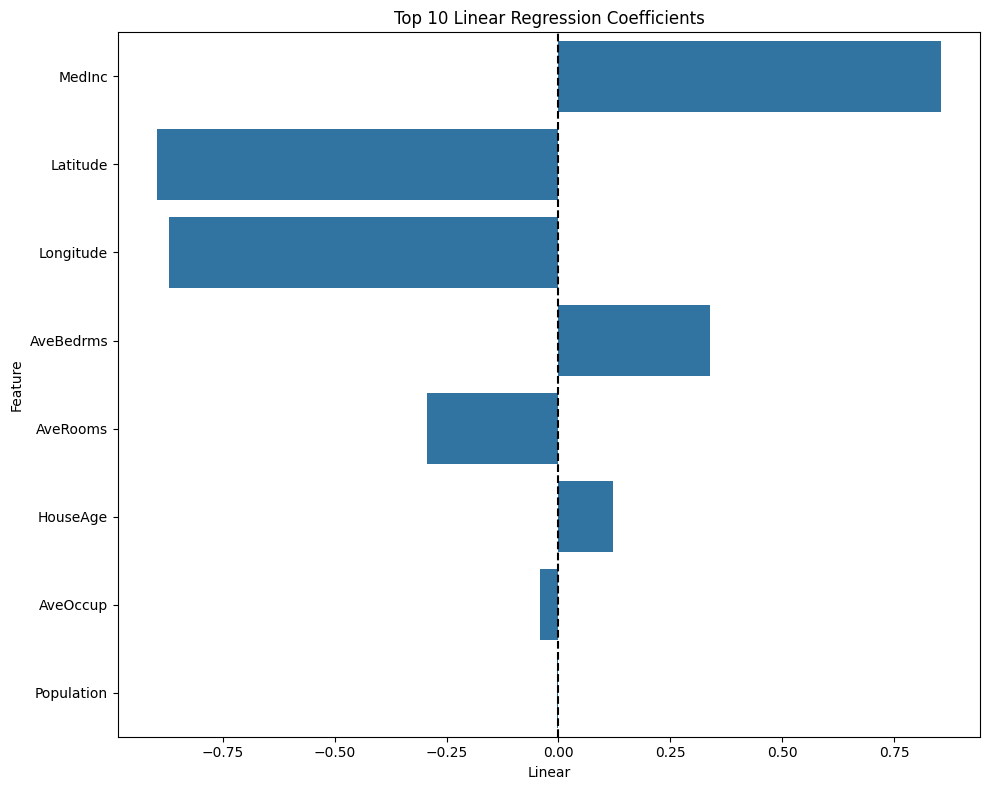

In [12]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
})

coef_df['Abs_Mean'] = coef_df[['Linear','Ridge','Lasso']].abs().mean(axis=1)
coef_df = coef_df.sort_values('Abs_Mean', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df.head(10), x='Linear', y='Feature')
plt.title('Top 10 Linear Regression Coefficients')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

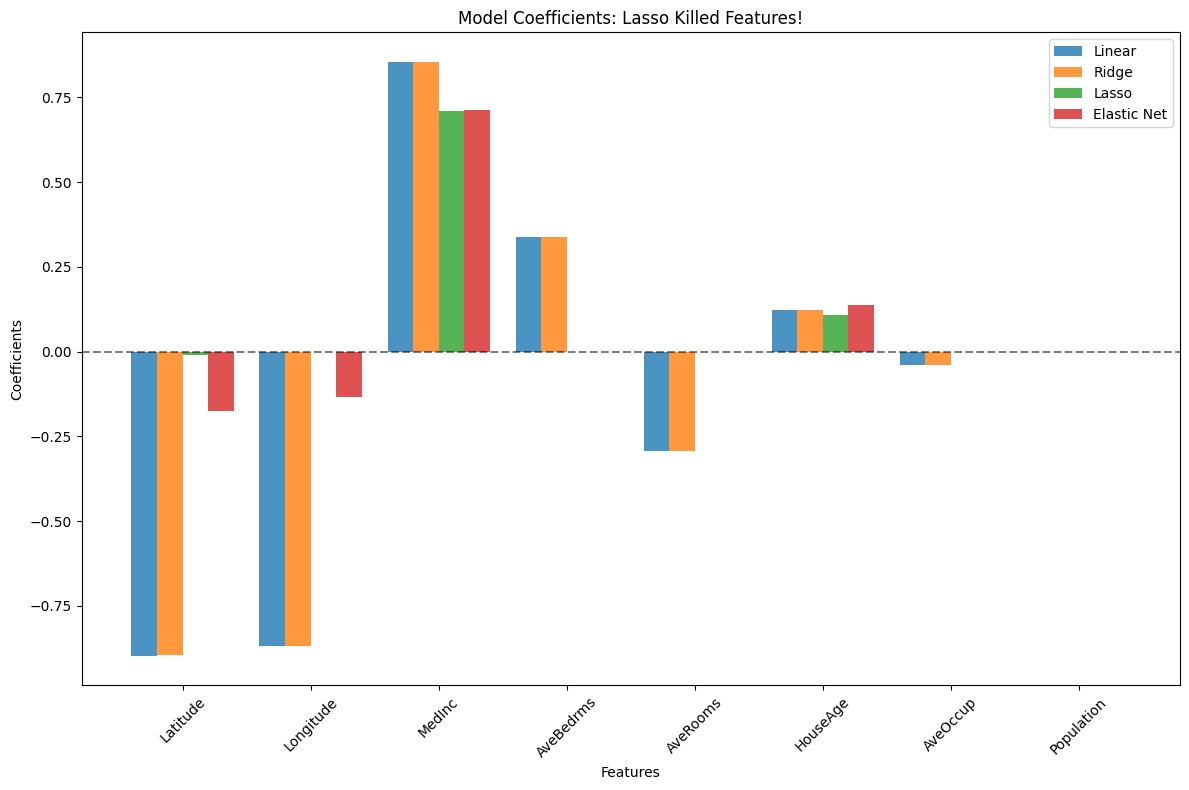

In [14]:
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
    'ElasticNet': enet_model.coef_
})

# Top 8 most important features
top_features = coef_comparison.reindex(
    coef_comparison['Linear'].abs().sort_values(ascending=False).index
).head(8)

plt.figure(figsize=(12, 8))
x = np.arange(len(top_features))
width = 0.2

plt.bar(x-0.3, top_features['Linear'], width, label='Linear', alpha=0.8)
plt.bar(x-0.1, top_features['Ridge'], width, label='Ridge', alpha=0.8)
plt.bar(x+0.1, top_features['Lasso'], width, label='Lasso', alpha=0.8)
plt.bar(x+0.3, top_features['ElasticNet'], width, label='Elastic Net', alpha=0.8)

plt.xlabel('Features'); plt.ylabel('Coefficients')
plt.title('Model Coefficients: Lasso Killed Features!')
plt.xticks(x, top_features['Feature'], rotation=45)
plt.legend()
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

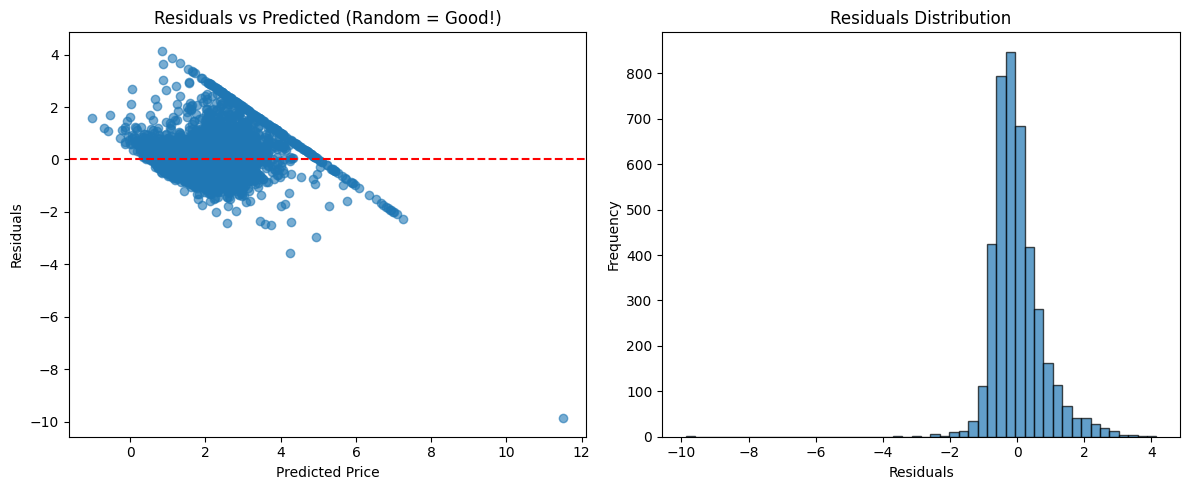

In [17]:
lr_residuals = y_test - lr_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(lr_pred, lr_residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price'); plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Random = Good!)')

plt.subplot(1, 2, 2)
plt.hist(lr_residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals'); plt.ylabel('Frequency')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()

#### Key Insights:
- Linear Regression and Ridge performed similarly, indicating low overfitting  
- Lasso reduced some feature coefficients to zero, performing feature selection  
- Elastic Net provided a balance between stability and sparsity  
- Median Income was the most influential feature  
- Residual analysis showed good model fit with minimal bias  

#### Conclusion:
This project demonstrates how regularization techniques improve regression performance and model stability. It highlights the importance of comparing models and understanding the bias-variance tradeoff for better generalization.